In [1]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA e bounds
- salvataggio fit

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3773/NGC-3773_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3773/NGC-3773_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


In [4]:
image_cut = image[70:170, 0:1890]
image_error_cut = image_error[70:170, 0:1890]

Text(0.5, 0, 'wavelength')

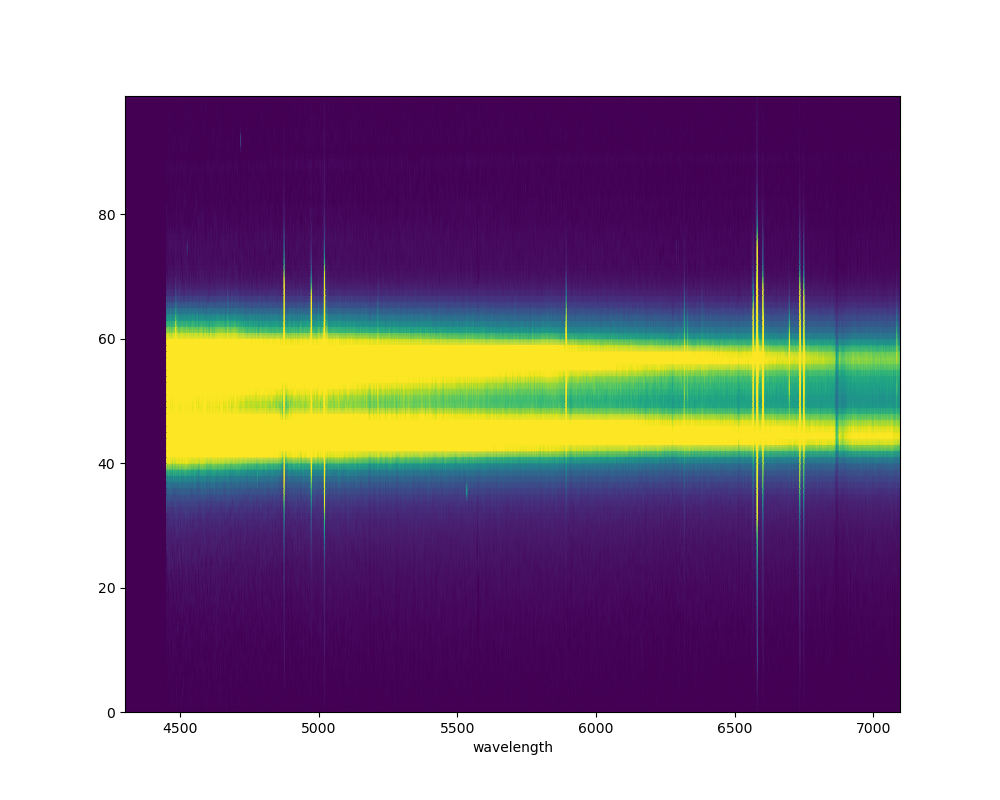

In [5]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [6]:
z = 0.00328
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3773/PSF/Real_seeing_NGC3773.txt")
sigmas = seeing / 2.35
n_component = 4
print(sigmas)

[1.01016511 1.12309039 1.00840577 0.99664427 1.1197505  1.01319149]


In [7]:
l_HA

6584.52664

## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3773/NGC-3773_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

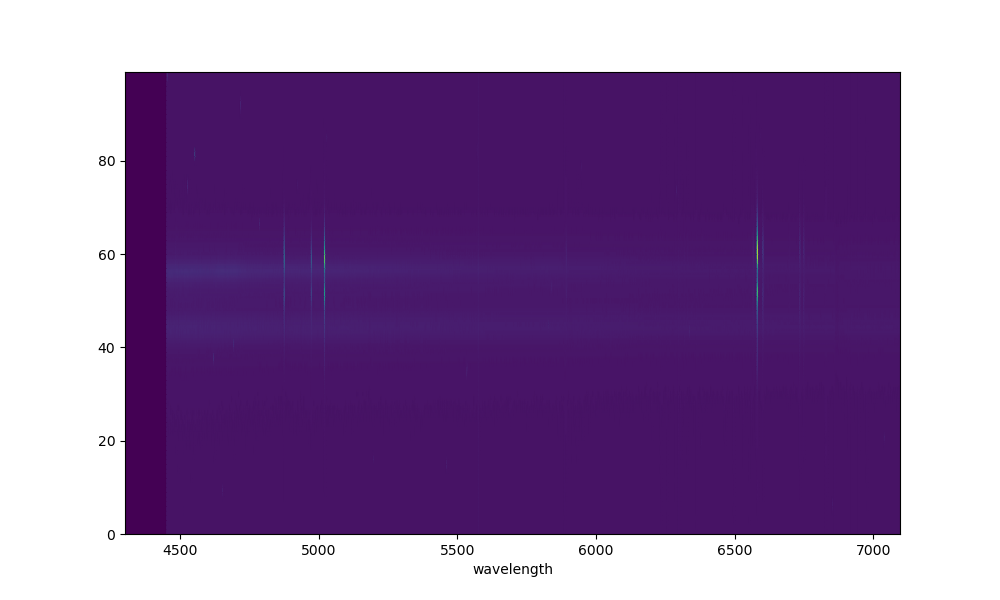

In [8]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3773/NGC-3773_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[70:170, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

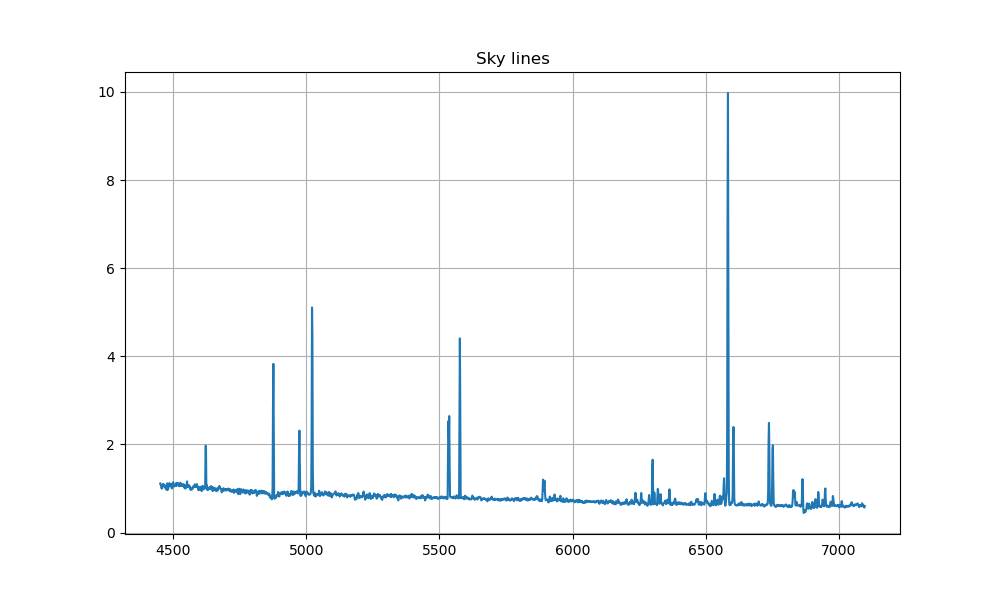

In [9]:
mask_sky = (y > 28)*(y < 38)
mask_wv = wv > 4450.5
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

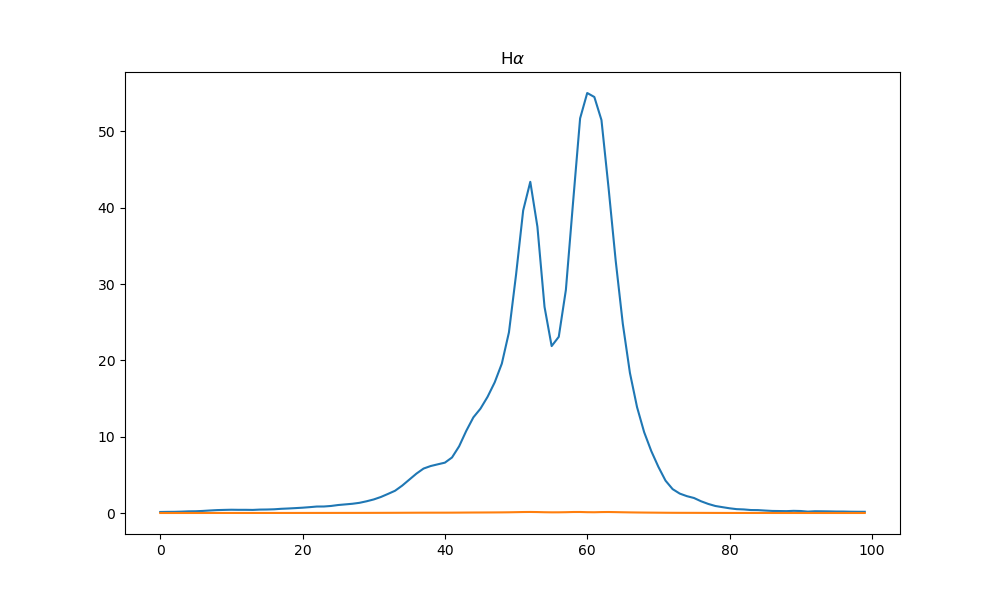

In [10]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3773/Propag_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [11]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) #+
        #sersic_1d(x_hr, *params[16:20])+ 
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 100)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 100)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [
    (0, 20),
    (0, 50),
    (0.1, 10),
    (43, 45),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (48, 53),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (57, 62), 

     (0, 20),
    (0, 50),
    (0.1, 10),
    (34, 37)
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

def save_params_diff(params_curve, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    param_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    
    output_dir = "Diff_params"
    os.makedirs(output_dir, exist_ok=True)

    # Salva file CSV nella cartella Diff_params
    if line_name:
        param_filename = os.path.join(output_dir, f"{line_name}_{output_prefix}_diff.csv")
    
    df_params.to_csv(param_filename, float_format='%.4f')

In [12]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 47092.87540143742
differential_evolution step 2: f(x)= 47092.87540143742
differential_evolution step 3: f(x)= 26059.337054323165
differential_evolution step 4: f(x)= 24896.37243096974
differential_evolution step 5: f(x)= 13274.756689989123
differential_evolution step 6: f(x)= 13213.45313235338
differential_evolution step 7: f(x)= 3628.7125970809307
differential_evolution step 8: f(x)= 3628.7125970809307
differential_evolution step 9: f(x)= 3436.4184688192363
differential_evolution step 10: f(x)= 3436.4184688192363
differential_evolution step 11: f(x)= 3436.4184688192363
differential_evolution step 12: f(x)= 3436.4184688192363
differential_evolution step 13: f(x)= 3436.4184688192363
differential_evolution step 14: f(x)= 3436.4184688192363
differential_evolution step 15: f(x)= 3436.4184688192363
differential_evolution step 16: f(x)= 3436.4184688192363
differential_evolution step 17: f(x)= 3436.4184688192363
differential_evolution step 18: f(x)= 3436.4

Sérsic 1: I_e=1.4502, r_e=17.9791, n=1.4481, x_0=45.0000
Sérsic 2: I_e=18.2235, r_e=1.9069, n=0.5310, x_0=51.4456
Sérsic 3: I_e=17.2330, r_e=5.2162, n=0.8125, x_0=60.7052
Sérsic 4: I_e=1.2618, r_e=1.7972, n=0.1000, x_0=36.5380


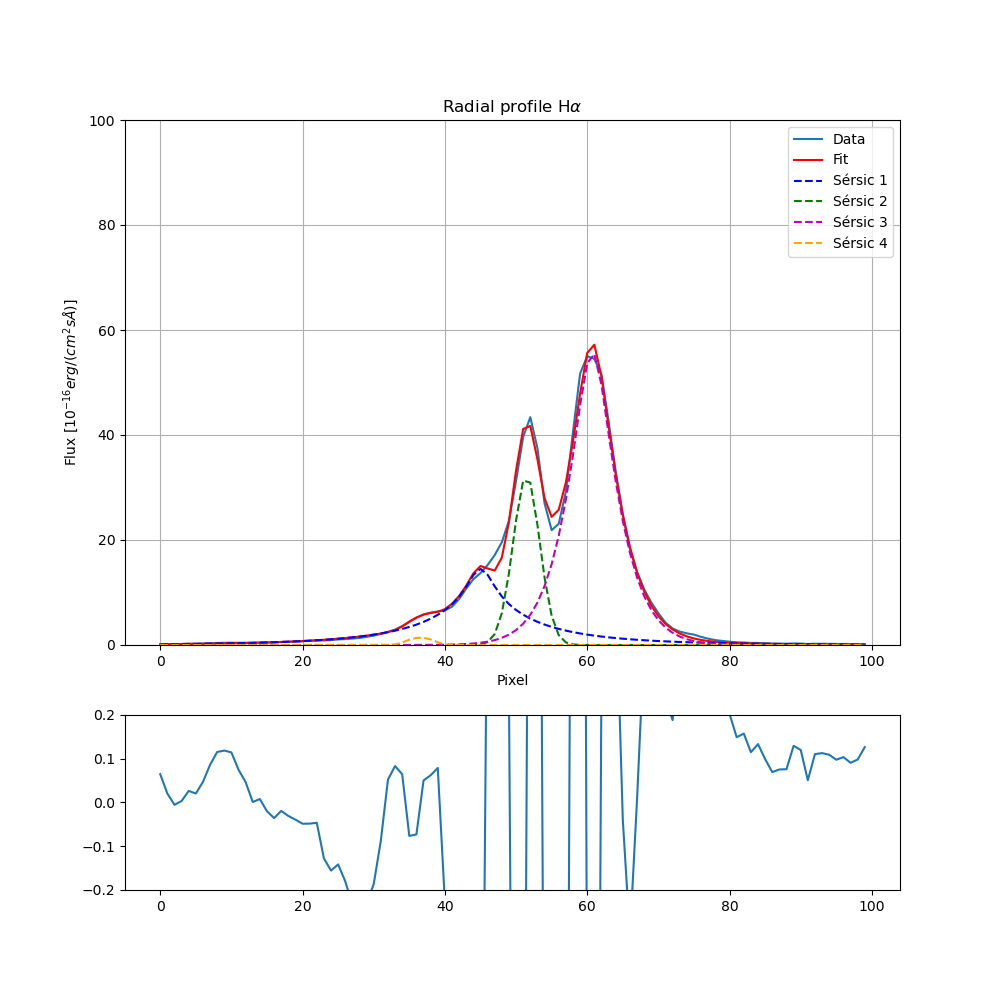

In [13]:
save_params_diff(best_params, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [14]:
print(result.x)

[ 1.45016054 17.97913314  1.44806567 45.         18.22352727  1.90690902
  0.53102959 51.44564547 17.23296495  5.21618941  0.81249192 60.70521319
  1.26179644  1.79721901  0.1        36.53796387]


In [15]:
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, p0=result.x, 
                                           sigma = real_errors_HA)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_10912\2569162179.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_10912\2569162179.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.8522, r_e=24.1543, n=1.7454, x_0=46.6771
Sérsic 2: I_e=22.8040, r_e=1.5782, n=0.3645, x_0=51.5754
Sérsic 3: I_e=15.0789, r_e=5.5621, n=0.9123, x_0=60.7191
Sérsic 4: I_e=1.9833, r_e=6.0734, n=0.2599, x_0=41.5792
[0.12399254 1.53414679 0.18699586 0.38693807 7.43203654 0.25989835
 0.27522534 0.22721331 0.47677262 0.08376084 0.03010378 0.08553952
 1.14410486 5.94362422 0.23387431 9.38970286]
2.0255578257867253


In [16]:
dof_HA

84

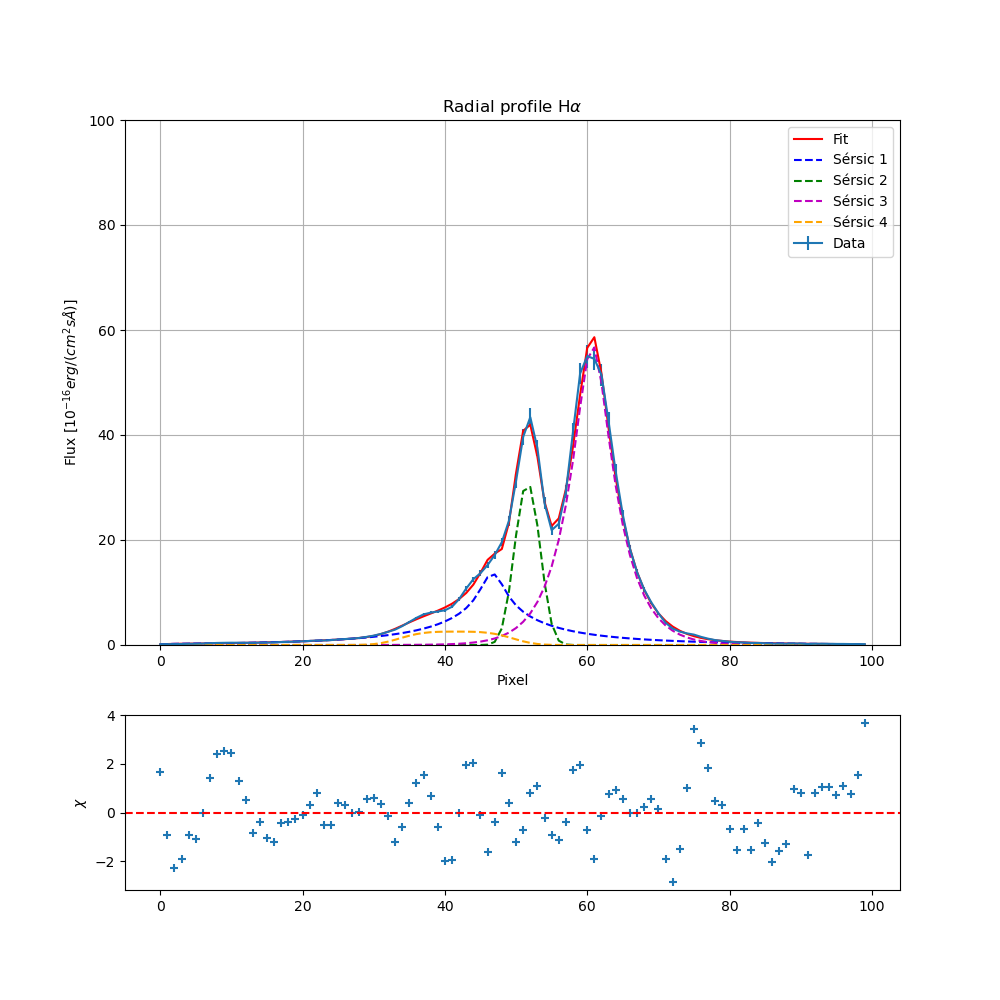

In [17]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, real_errors_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [18]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds = [
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.2, x_0_HA[0]+1.2),   # x_0: circa la posizione di Halpha

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.2, x_0_HA[1]+1.2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.2, x_0_HA[2]+1.2),
]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

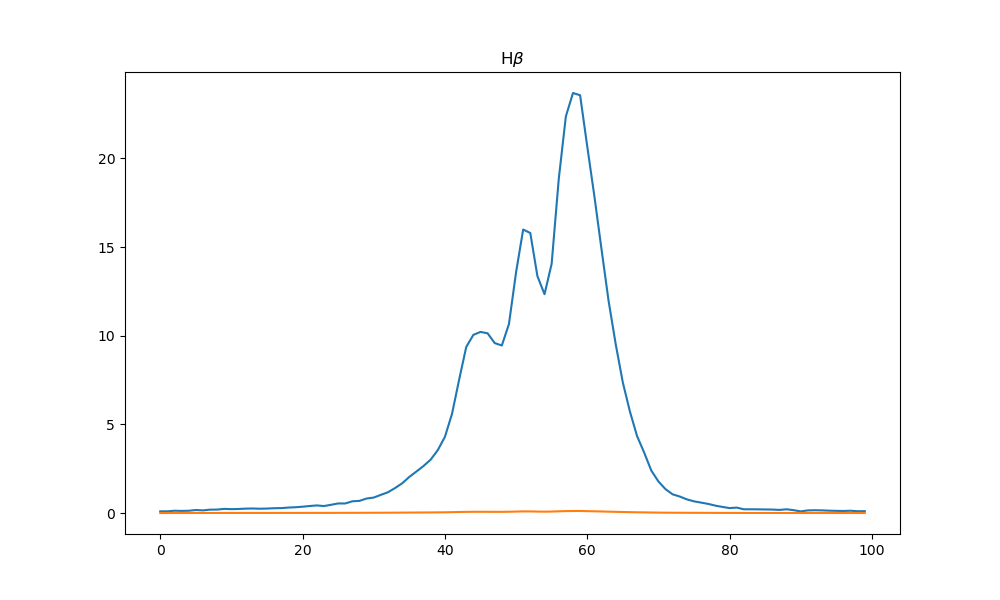

In [37]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))

real_errors_HB = np.sqrt(radial_profile_error_HB**2+(sky_err[0])**2+(0.04*radial_profile_HB)**2)

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [38]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 12630.68836960947
differential_evolution step 2: f(x)= 12630.68836960947
differential_evolution step 3: f(x)= 10598.90493382074
differential_evolution step 4: f(x)= 2981.9747324117848
differential_evolution step 5: f(x)= 2981.9747324117848
differential_evolution step 6: f(x)= 2755.963096942193
differential_evolution step 7: f(x)= 2755.963096942193
differential_evolution step 8: f(x)= 2755.963096942193
differential_evolution step 9: f(x)= 2665.1559007090264
differential_evolution step 10: f(x)= 1119.0402469874907
differential_evolution step 11: f(x)= 1119.0402469874907
differential_evolution step 12: f(x)= 688.0148200899288
differential_evolution step 13: f(x)= 666.3235673712722
differential_evolution step 14: f(x)= 666.3235673712722
differential_evolution step 15: f(x)= 666.3235673712722
differential_evolution step 16: f(x)= 666.3235673712722
differential_evolution step 17: f(x)= 666.3235673712722
differential_evolution step 18: f(x)= 666.3235673712


KeyboardInterrupt



In [ ]:
save_params_diff(best_params, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="HBeta", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [ ]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), 
                                           x_axes, radial_profile_HB, p0=result.x, sigma = real_errors_HB, bounds = bounds_list, maxfev = 10000)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

In [ ]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, real_errors_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

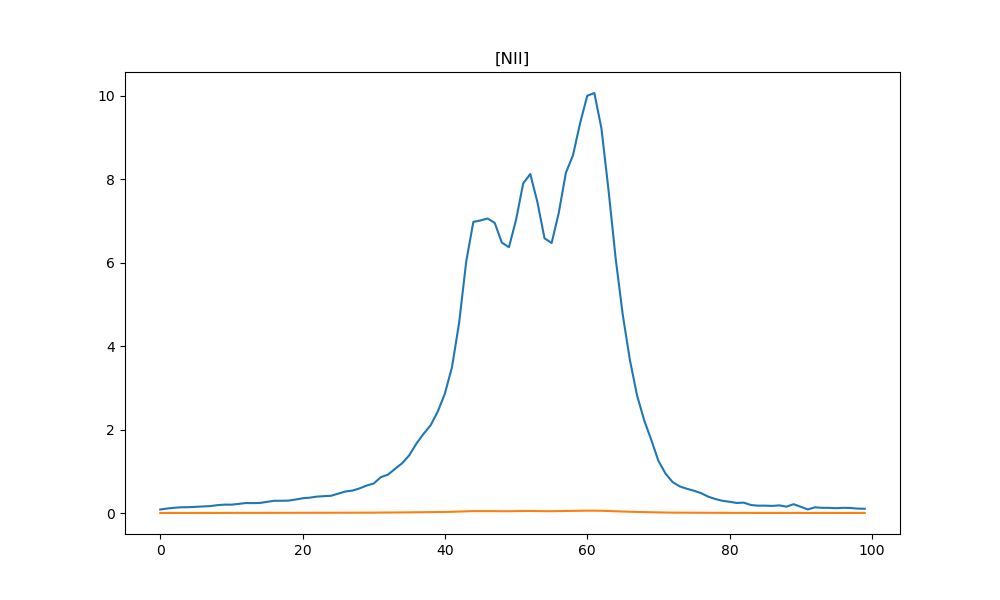

In [12]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))

real_errors_NII = np.sqrt(radial_profile_error_NII**2+(sky_err[2])**2+(0.04*radial_profile_NII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [123]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 2109.7768729956792
differential_evolution step 2: f(x)= 2007.096748064301
differential_evolution step 3: f(x)= 1616.4075799252892
differential_evolution step 4: f(x)= 1616.4075799252892
differential_evolution step 5: f(x)= 1304.1431079595127
differential_evolution step 6: f(x)= 1304.1431079595127
differential_evolution step 7: f(x)= 1228.8010051620213
differential_evolution step 8: f(x)= 1228.8010051620213
differential_evolution step 9: f(x)= 1228.8010051620213
differential_evolution step 10: f(x)= 1228.8010051620213
differential_evolution step 11: f(x)= 1228.8010051620213
differential_evolution step 12: f(x)= 1177.093060268218
differential_evolution step 13: f(x)= 1177.093060268218
differential_evolution step 14: f(x)= 1177.093060268218
differential_evolution step 15: f(x)= 1126.2261239907386
differential_evolution step 16: f(x)= 1126.2261239907386
differential_evolution step 17: f(x)= 1126.2261239907386
differential_evolution step 18: f(x)= 1102.4

Sérsic 1: I_e=0.1000, r_e=50.0000, n=5.2575, x_0=39.3746
Sérsic 2: I_e=0.1000, r_e=49.9999, n=3.0907, x_0=48.7750
Sérsic 3: I_e=0.1000, r_e=49.9993, n=2.6903, x_0=56.8897


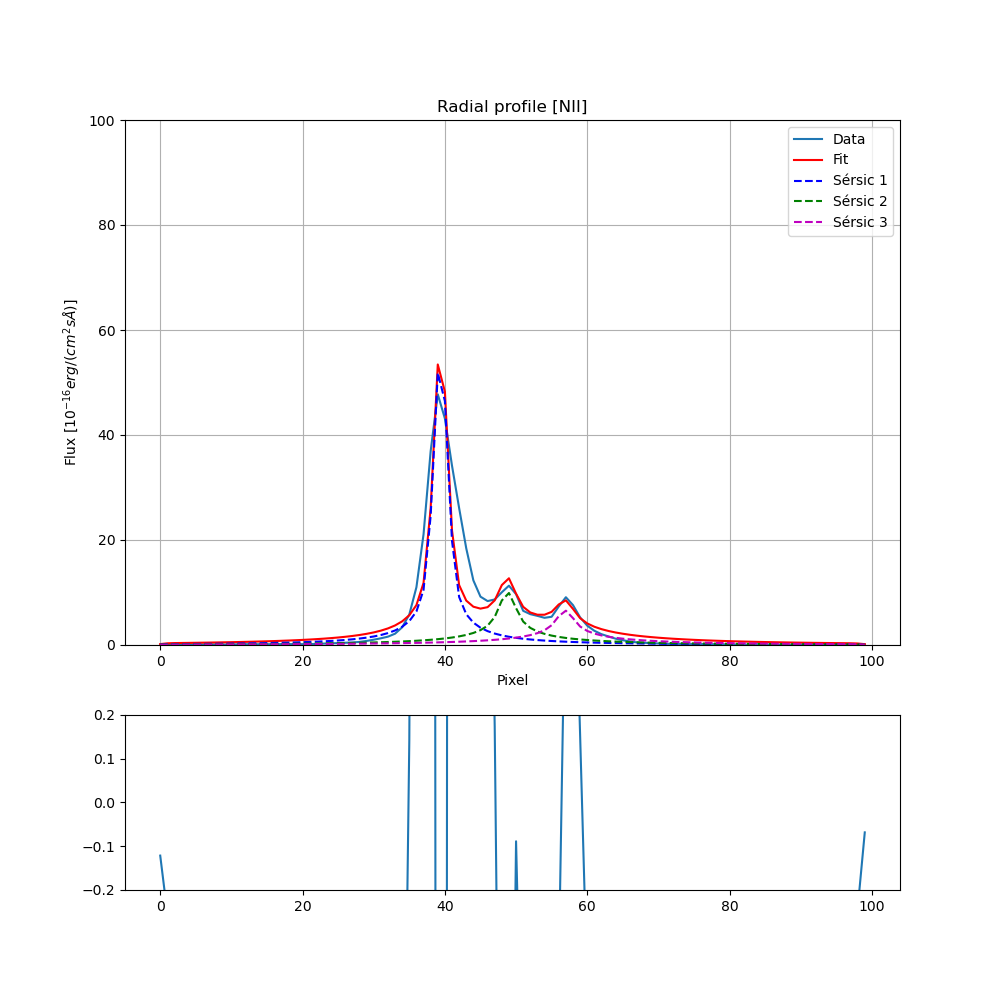

In [124]:
# Plots:
save_params_diff(best_params, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [125]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = real_errors_NII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.1000, r_e=33.9586, n=6.0531, x_0=39.3253
Sérsic 2: I_e=0.1000, r_e=28.4905, n=3.6173, x_0=49.1008
Sérsic 3: I_e=0.1000, r_e=21.6193, n=3.4535, x_0=56.8820
[5.97509037e-01 1.35876390e+02 5.75232369e+00 1.43853739e-01
 8.34056217e-01 2.01129099e+02 6.01517663e+00 2.34195699e-01
 5.83134145e-01 1.04253622e+02 4.42008736e+00 2.37377586e-01]
32.5147633482137


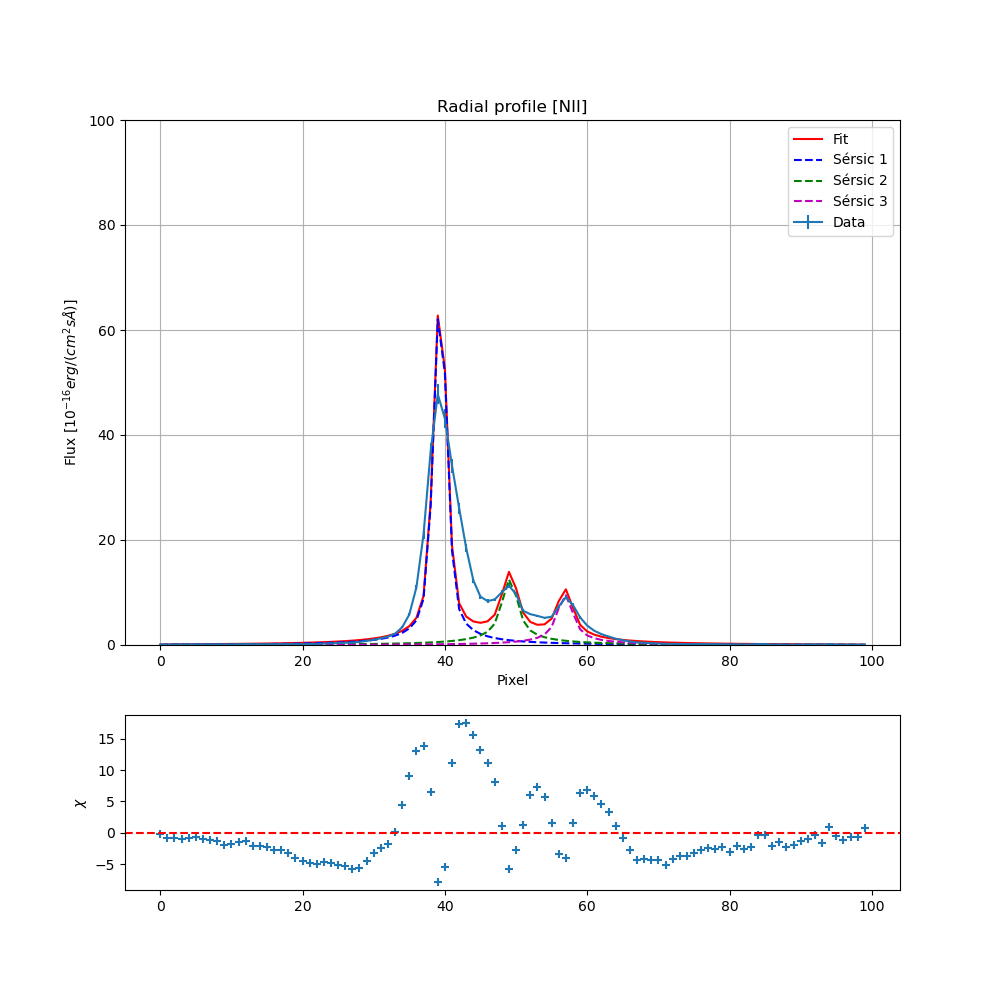

In [126]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, real_errors_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

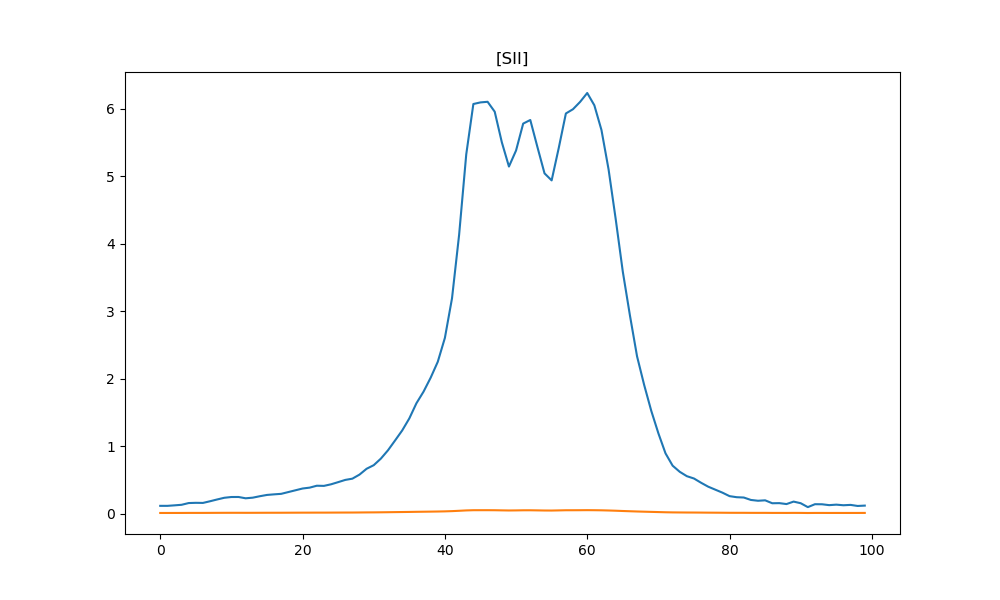

In [13]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))

real_errors_SII = np.sqrt(radial_profile_error_SII**2+(sky_err[3])**2+(0.04*radial_profile_SII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [130]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 393.66947003111744
differential_evolution step 2: f(x)= 188.88083999065364
differential_evolution step 3: f(x)= 188.88083999065364
differential_evolution step 4: f(x)= 188.88083999065364
differential_evolution step 5: f(x)= 188.88083999065364
differential_evolution step 6: f(x)= 188.88083999065364
differential_evolution step 7: f(x)= 188.88083999065364
differential_evolution step 8: f(x)= 188.88083999065364
differential_evolution step 9: f(x)= 188.88083999065364
differential_evolution step 10: f(x)= 188.88083999065364
differential_evolution step 11: f(x)= 188.88083999065364
differential_evolution step 12: f(x)= 184.46149839909867
differential_evolution step 13: f(x)= 184.46149839909867
differential_evolution step 14: f(x)= 184.46149839909867
differential_evolution step 15: f(x)= 184.46149839909867
differential_evolution step 16: f(x)= 184.46149839909867
differential_evolution step 17: f(x)= 184.07809291787
differential_evolution step 18: f(x)= 184.0

Sérsic 1: I_e=0.1000, r_e=50.0000, n=3.8976, x_0=39.8451
Sérsic 2: I_e=0.1000, r_e=50.0000, n=2.4202, x_0=48.7750
Sérsic 3: I_e=0.1000, r_e=10.1684, n=2.7451, x_0=57.4726


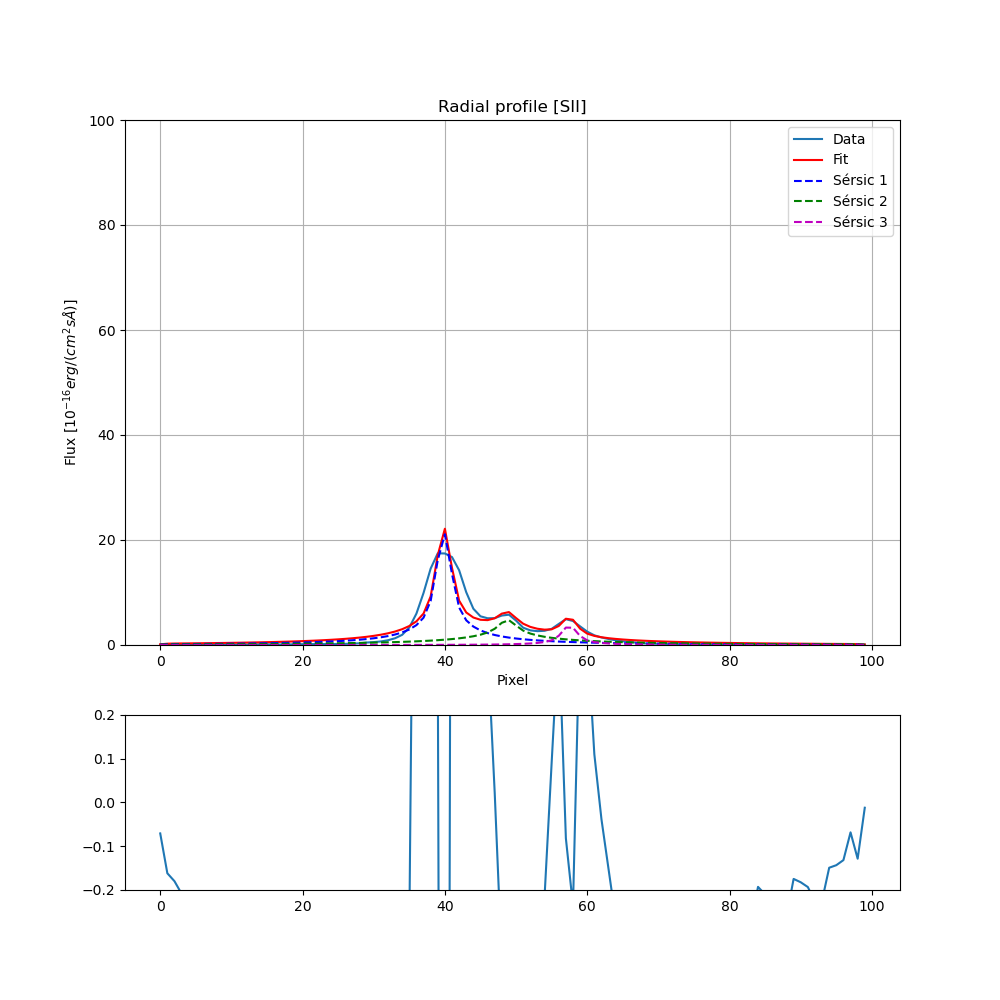

In [131]:
save_params_diff(best_params, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [132]:
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = real_errors_SII)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_9692\1087897001.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_9692\1087897001.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=7.4727, r_e=3.1565, n=0.6369, x_0=39.9557
Sérsic 2: I_e=0.3055, r_e=19.9111, n=1.8539, x_0=48.3834
Sérsic 3: I_e=0.8836, r_e=4.0902, n=1.0310, x_0=57.5603
[0.24572331 0.05600399 0.02680349 0.04195344 0.05122814 1.68020931
 0.12520474 0.08961789 0.10787154 0.35668427 0.09459162 0.07275295]
0.9287791802233522


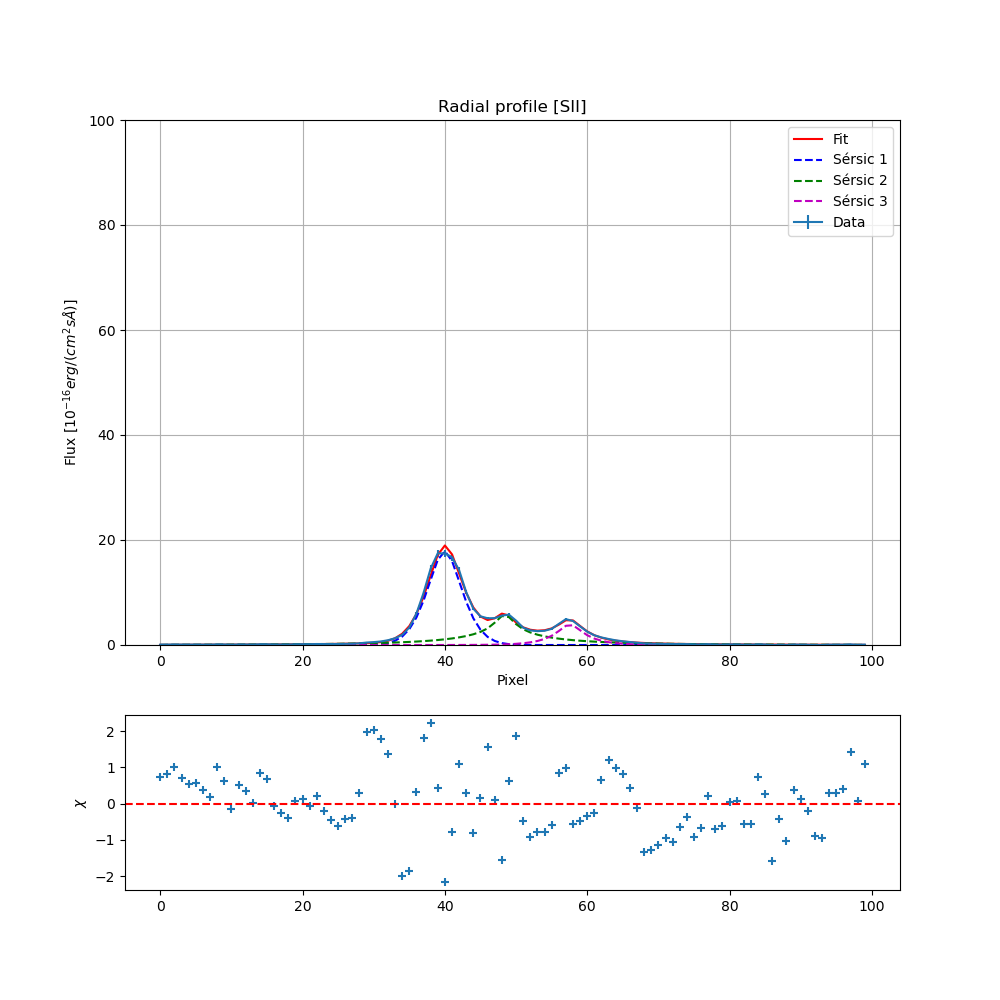

In [133]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, real_errors_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

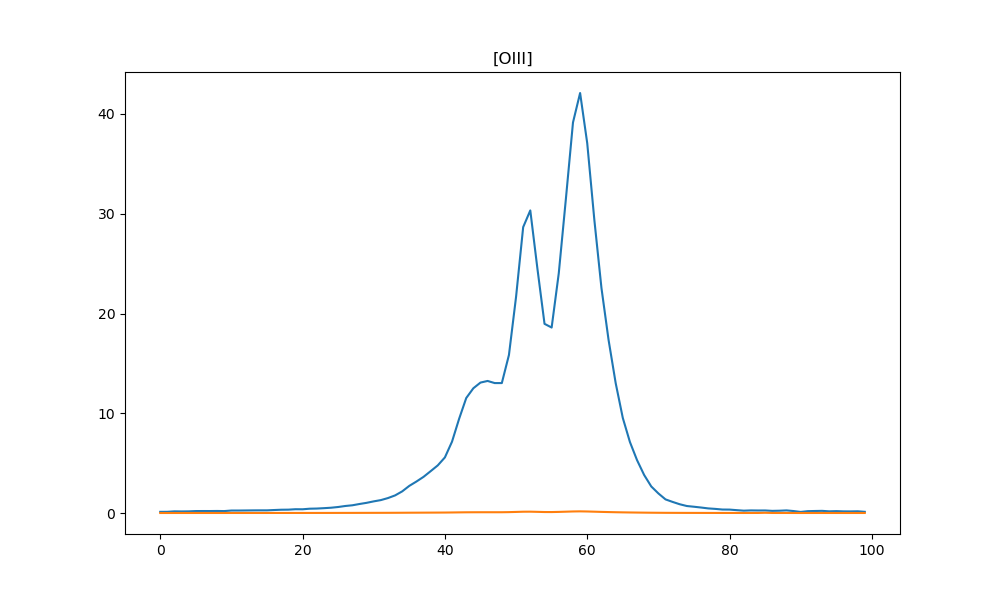

In [14]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))

real_errors_OIII = np.sqrt(radial_profile_error_OIII**2+(sky_err[1])**2+(0.04*radial_profile_OIII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [135]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 257.95930863674215
differential_evolution step 2: f(x)= 246.8626612643744
differential_evolution step 3: f(x)= 240.6311746976442
differential_evolution step 4: f(x)= 240.6311746976442
differential_evolution step 5: f(x)= 240.6311746976442
differential_evolution step 6: f(x)= 219.22077385090614
differential_evolution step 7: f(x)= 167.60620986389705
differential_evolution step 8: f(x)= 167.60620986389705
differential_evolution step 9: f(x)= 167.60620986389705
differential_evolution step 10: f(x)= 167.60620986389705
differential_evolution step 11: f(x)= 134.45815566687153
differential_evolution step 12: f(x)= 134.45815566687153
differential_evolution step 13: f(x)= 134.45815566687153
differential_evolution step 14: f(x)= 134.45815566687153
differential_evolution step 15: f(x)= 121.19666401816731
differential_evolution step 16: f(x)= 121.19666401816731
differential_evolution step 17: f(x)= 98.10902049530844
differential_evolution step 18: f(x)= 98.1090

Sérsic 1: I_e=0.1000, r_e=50.0000, n=4.0120, x_0=40.0925
Sérsic 2: I_e=0.1000, r_e=42.8597, n=2.3182, x_0=48.7770
Sérsic 3: I_e=0.1000, r_e=19.4982, n=2.8381, x_0=58.1217


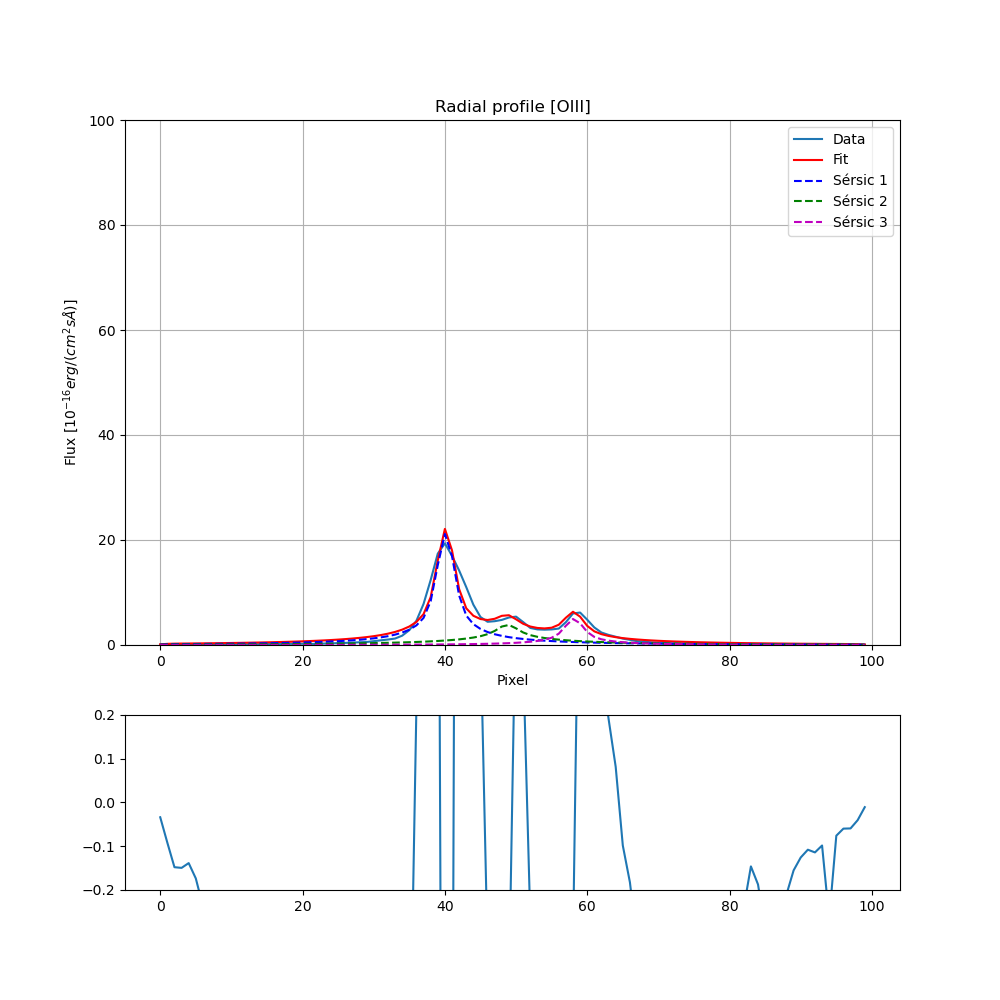

In [136]:
# Plots:
save_params_diff(best_params, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [137]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = real_errors_OIII)#, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_9692\1087897001.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_9692\1087897001.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=6.8098, r_e=3.0679, n=0.7468, x_0=40.2378
Sérsic 2: I_e=0.2836, r_e=26.1162, n=1.8156, x_0=49.2112
Sérsic 3: I_e=0.8518, r_e=4.3777, n=1.2997, x_0=58.8544
[0.32195857 0.08100342 0.04008247 0.04083566 0.05760719 2.87687936
 0.14315003 0.11328299 0.16052482 0.59536205 0.14898114 0.06439877]
0.9144908820493172


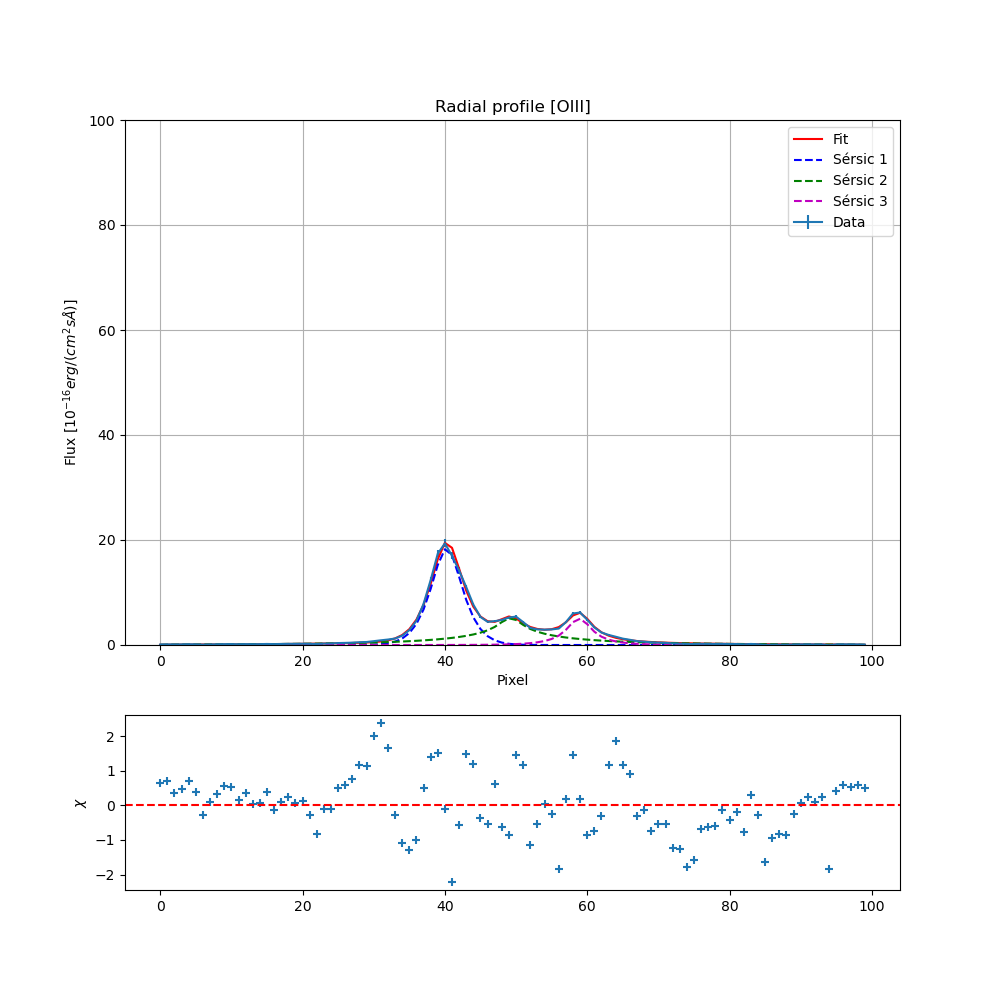

In [138]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [139]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

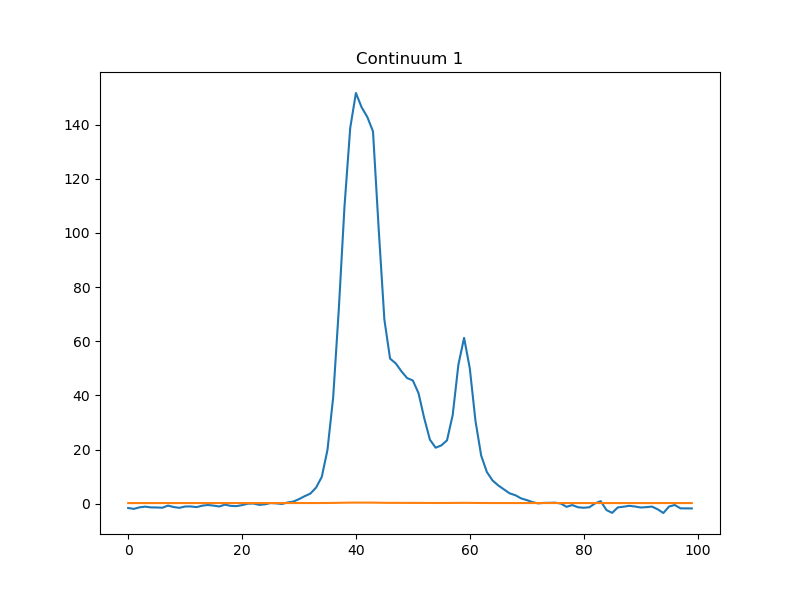

In [140]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))

real_errors_c1 = np.sqrt(radial_profile_error_continuum_1**2+(sky_err[0])**2+(0.04*radial_profile_continuum_1)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [141]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 19992.286459297047
differential_evolution step 2: f(x)= 19992.286459297047
differential_evolution step 3: f(x)= 19992.286459297047
differential_evolution step 4: f(x)= 19132.74950406945
differential_evolution step 5: f(x)= 19132.74950406945
differential_evolution step 6: f(x)= 16554.572025538124
differential_evolution step 7: f(x)= 16554.572025538124
differential_evolution step 8: f(x)= 16554.572025538124
differential_evolution step 9: f(x)= 16554.572025538124
differential_evolution step 10: f(x)= 15855.365609435401
differential_evolution step 11: f(x)= 15293.787170562931
differential_evolution step 12: f(x)= 15293.787170562931
differential_evolution step 13: f(x)= 11704.283735503237
differential_evolution step 14: f(x)= 10462.543240146688
differential_evolution step 15: f(x)= 10462.543240146688
differential_evolution step 16: f(x)= 10462.543240146688
differential_evolution step 17: f(x)= 10462.543240146688
differential_evolution step 18: f(x)= 1046

In [142]:
def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)    

Sérsic 1: I_e=10.0000, r_e=11.6135, n=1.8818, x_0=40.5877
Sérsic 2: I_e=10.0000, r_e=7.8844, n=0.7978, x_0=46.0000
Sérsic 3: I_e=4.2916, r_e=5.6071, n=1.9762, x_0=59.0484


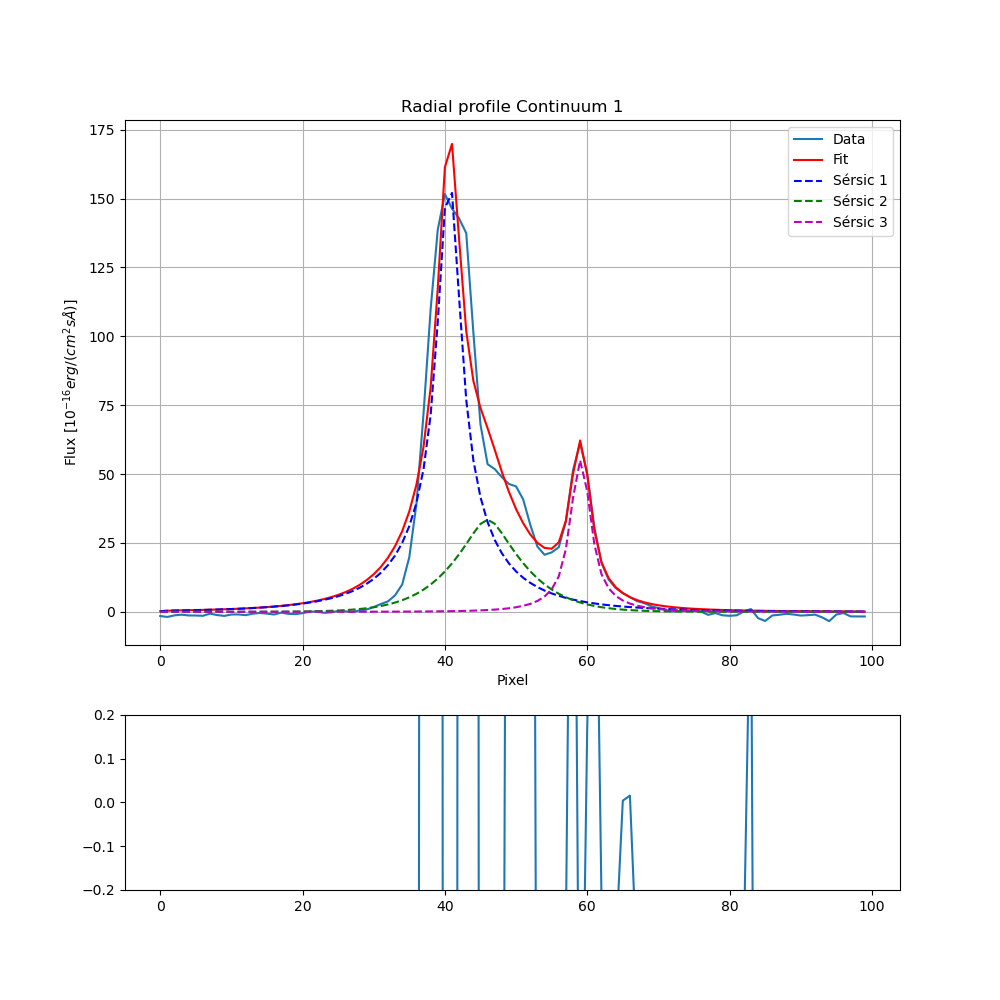

In [143]:
save_params_diff(best_params, radial_profile_continuum_1, real_errors_c1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [144]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = real_errors_c1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, 
                                                                          radial_profile_continuum_1, real_errors_c1, sigmas[1],
                                                                          x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=9.9460, r_e=5.5124, n=2.3770, x_0=40.5083
Sérsic 2: I_e=9.9997, r_e=7.1190, n=1.0371, x_0=47.7478
Sérsic 3: I_e=7.1876, r_e=4.7857, n=1.5081, x_0=59.0188
[14.80816006  6.2148834   1.20153194  0.2408382  11.69480181  8.6211868
  0.82040073  0.70515749  4.59089104  3.00498372  0.59549276  0.2573483 ]
29.939336281474517


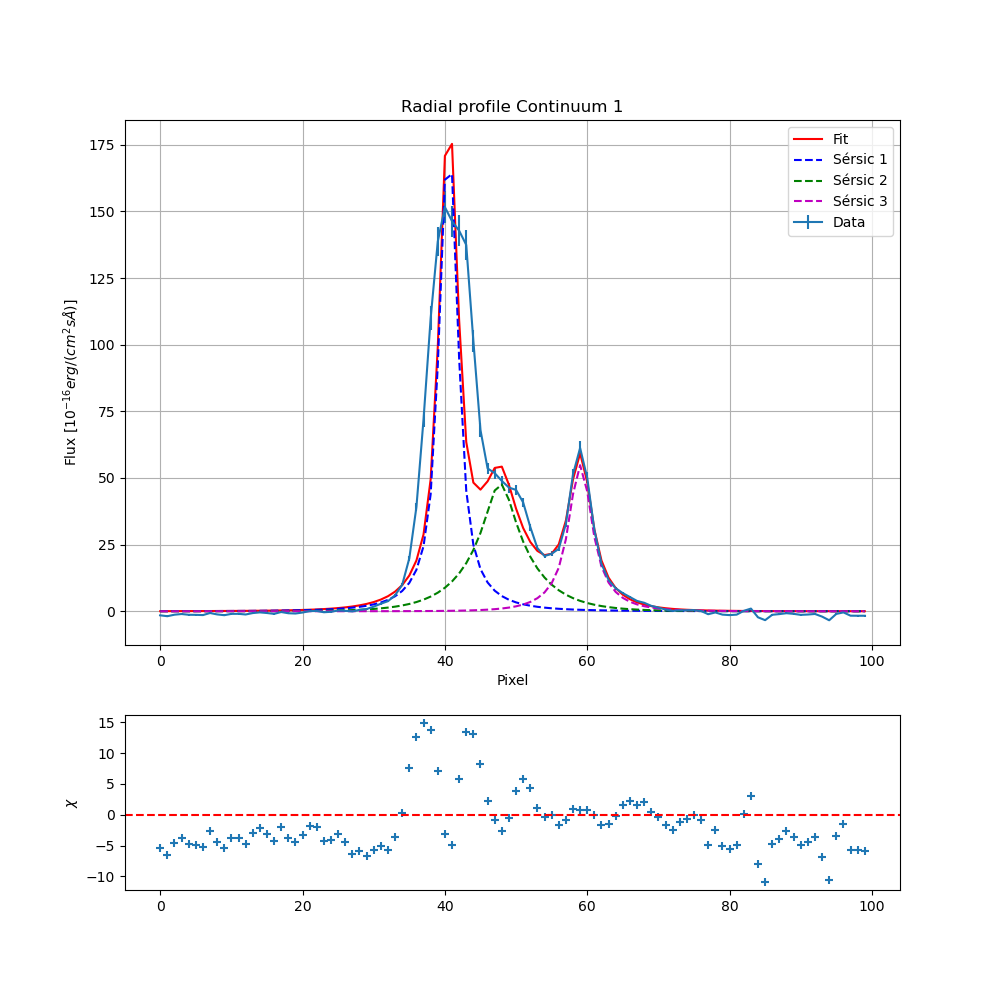

In [145]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, real_errors_c1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

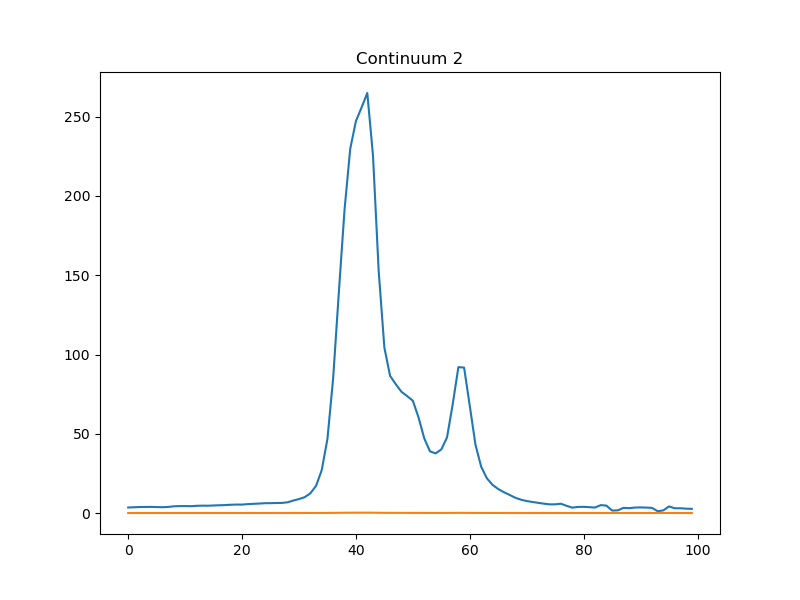

In [146]:
mask_continuum_2 = (wv > 5300)*(wv < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))

real_errors_c2 = np.sqrt(radial_profile_error_continuum_2**2+(sky_err[2])**2+(0.04*radial_profile_continuum_2)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [ ]:
# Bounds:
bounds = bounds_HA
seeing_i = 3.174
sigma_i = seeing_i/ 2.35

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigma_i)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 89291.22364274372
differential_evolution step 2: f(x)= 34332.2494595456
differential_evolution step 3: f(x)= 34332.2494595456
differential_evolution step 4: f(x)= 34332.2494595456
differential_evolution step 5: f(x)= 34332.2494595456
differential_evolution step 6: f(x)= 34332.2494595456
differential_evolution step 7: f(x)= 34332.2494595456
differential_evolution step 8: f(x)= 26380.953281791408
differential_evolution step 9: f(x)= 26380.953281791408
differential_evolution step 10: f(x)= 26380.953281791408
differential_evolution step 11: f(x)= 25321.605194847914
differential_evolution step 12: f(x)= 22146.719776015565
differential_evolution step 13: f(x)= 20815.5855955456
differential_evolution step 14: f(x)= 20815.5855955456
differential_evolution step 15: f(x)= 20815.5855955456
differential_evolution step 16: f(x)= 18696.966448777464
differential_evolution step 17: f(x)= 18696.966448777464
differential_evolution step 18: f(x)= 16048.749327479138
di

In [ ]:
save_params_diff(best_params, radial_profile_continuum_2, real_errors_c2, sigma_i,
    x_axes, n_component, line_name="Continuum_2", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigma_i, r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [ ]:
bounds = bounds_HA
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigma_i, *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = real_errors_c2, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
                                                                          real_errors_c2, sigma_i, x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

In [ ]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, real_errors_c2, sigma_i, r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

In [ ]:
mask_continuum_3 = (wv > 6000)*(wv < 6500)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))

real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [ ]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

In [ ]:
save_params_diff(best_params, radial_profile_continuum_3, real_errors_c3, sigmas[0],
    x_axes, n_component, line_name="Continuum_3", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [ ]:
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = real_errors_c3)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          real_errors_c3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

In [ ]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, real_errors_c3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

In [ ]:
d1 = {'Name': ['Continuum 3'], 'Chi squared': chi2_continuum_3,
      'Dof': dof_continuum_3, 'Chi reduced': chi2_reduced_continuum_3}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_continuum_3.csv", index= False)

## Chi squared save

In [ ]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII, 
           chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII, 
           dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII, 
           chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII', 'Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)